# Preprocessing version 2
Preprocessing feels somewhat arbitrary in Scanpy compared to R. Here I will try to follow the tutorial from scirpy (TCR analysis) to merge transcriptomic and VDJ information into one object

In [82]:
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import scirpy as ir
import seaborn as sb
import scrublet as scr
from matplotlib import cm as mpl_cm
from matplotlib import pyplot as plt
from scipy.stats import median_abs_deviation

sc.set_figure_params(figsize=(4, 4))
sc.settings.verbosity = 2  # verbosity: errors (0), warnings (1), info (2), hints (3)

In [83]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rc('font', size=14)
plt.rcParams['pdf.fonttype'] = 42

# Loading data

In [84]:
path_data = "..\\..\\02_raw_data"
path_gex_NK1 = f"{path_data}\\runs\\NK_1EBV\\count\\sample_filtered_feature_bc_matrix.h5"
path_tcr_NK1 = f"{path_data}\\runs\\NK_1EBV\\vdj_t\\filtered_contig_annotations.csv"

First we load a conventional AnnData object with GEX information. We seperately load an AnnData object with TCR information and merge the two objects together into a MuData object (MultiOmicsData)

In [85]:
mdata = sc.read_10x_h5(path_gex_NK1, gex_only=False)
mdata.var_names_make_unique() #So that gene names are unique
mdata_tcr = ir.io.read_10x_vdj(path_tcr_NK1)
mdata = mu.MuData({"gex": mdata, "airr": mdata_tcr})

# Update 2025_7 - save the counts into a separate layer. 
mdata["gex"].layers["counts"] = mdata["gex"].X.copy()

reading ..\..\02_raw_data\runs\NK_1EBV\count\sample_filtered_feature_bc_matrix.h5
 (0:00:00)


C:\Users\nipag\miniconda3\envs\py312_laptop\Lib\site-packages\anndata\_core\anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
C:\Users\nipag\miniconda3\envs\py312_laptop\Lib\site-packages\mudata\_core\mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
C:\Users\nipag\miniconda3\envs\py312_laptop\Lib\site-packages\mudata\_core\mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_va

## Functions

In [86]:
tcr_gene_prefixs = ['TRAV', 'TRAJ', 'TRAC', 'TRB', 'TRDV', 'TRDC', 'TRG']

def filter_tcr_genes(adata):
    non_tcr_genes = adata.var_names
    for prefix in tcr_gene_prefixs:
        non_tcr_genes = [el for el in non_tcr_genes if not el.startswith(prefix)]
    adata = adata[:, non_tcr_genes]
    return adata


def filter_high_var(adata, n):
    sc.pp.highly_variable_genes(adata, n_top_genes=n)
    adata = adata[:, adata.var['highly_variable']].copy()
    return adata


def calculate_umap(adata, n_high_var=5000, remove_tcr_genes=True):
    """
    Calculates UMAP coordinates
    :param adata: AnnData object
    :param n_high_var: how many variable genes to use, None uses raw data
    :param remove_tcr_genes: whether to remove TCR genes
    :return: results stored in adata object
    """
    adata_tmp = adata.copy()

    if remove_tcr_genes:
        adata_tmp = filter_tcr_genes(adata_tmp)
    if n_high_var is not None:
        adata_tmp = filter_high_var(adata_tmp, n_high_var)

    sc.pp.neighbors(adata_tmp, n_pcs=20)            
    sc.tl.umap(adata_tmp)
    adata.obsm['X_umap'] = adata_tmp.obsm['X_umap']


def calculate_leiden(adata, resolution, n_high_var=5000, remove_tcr_genes=True):
    adata_tmp = adata.copy()

    if remove_tcr_genes:
        adata_tmp = filter_tcr_genes(adata_tmp)
    if n_high_var is not None:
        adata_tmp = filter_high_var(adata_tmp, n_high_var)

    sc.pp.neighbors(adata_tmp, n_pcs=20)
    sc.tl.leiden(adata_tmp, resolution=resolution)
    adata.obs['leiden'] = adata_tmp.obs['leiden']

## Scrublet
* First use scrublet to see how well doublets are predicted per sample
    * Guide on Github for running scrublet: https://github.com/swolock/scrublet/blob/master/examples/scrublet_basics.ipynb

In [87]:
ddata = mdata.copy() #Make a standalone copy of the data

C:\Users\nipag\miniconda3\envs\py312_laptop\Lib\site-packages\mudata\_core\mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
C:\Users\nipag\miniconda3\envs\py312_laptop\Lib\site-packages\mudata\_core\mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


#### Annotate using scrublet
Scrublet requires the raw gene count matrix. As we have not yet normalized our data. This should work

In [88]:
#Define a view variable for the count matrix
counts_matrix = ddata["gex"].layers["counts"]

In [89]:
## I have 4730 cells
ddata["gex"]

AnnData object with n_obs × n_vars = 4725 × 36686
    var: 'gene_ids', 'feature_types', 'genome'
    layers: 'counts'

In [90]:
## Anticipated doublet rate is aproximately given by ""Multiplet rate = 0.0008 * cells_recovered"" according to 10x Genomics tables. 
0.0008*4730

3.7840000000000003

In [91]:
scrub = scr.Scrublet(counts_matrix, expected_doublet_rate=0.0374)

In [92]:
#This is the default pipeline
doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts=2, 
                                                          min_cells=3, 
                                                          min_gene_variability_pctl=85, 
                                                          n_prin_comps=30)

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.45
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.5%
Overall doublet rate:
	Expected   = 3.7%
	Estimated  = 4.3%
Elapsed time: 3.9 seconds


* Surprisingly, scrublet never assigns doublet score likelihoods above 0.5 - the example online clear states that it is supposed to be a bimodal distribution

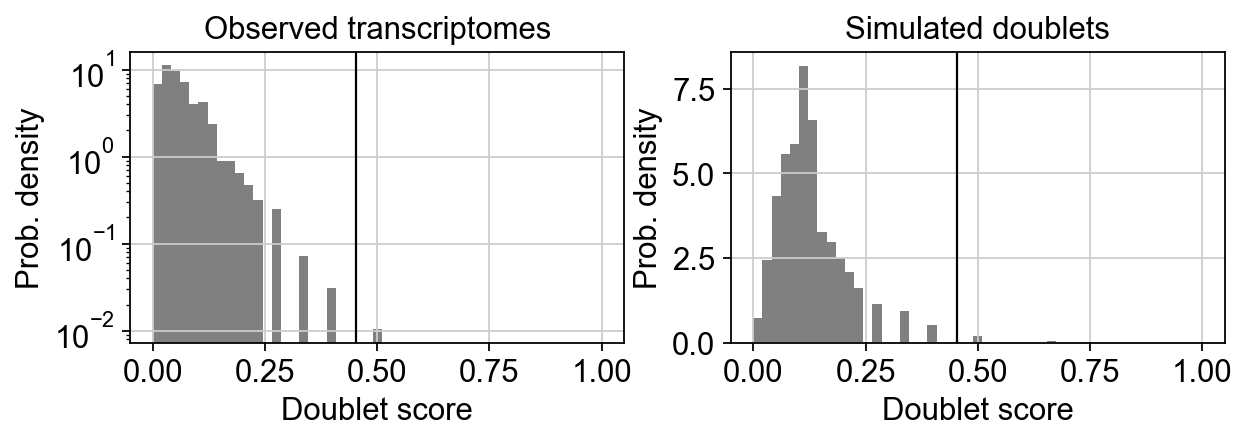

In [93]:
scrub.plot_histogram();

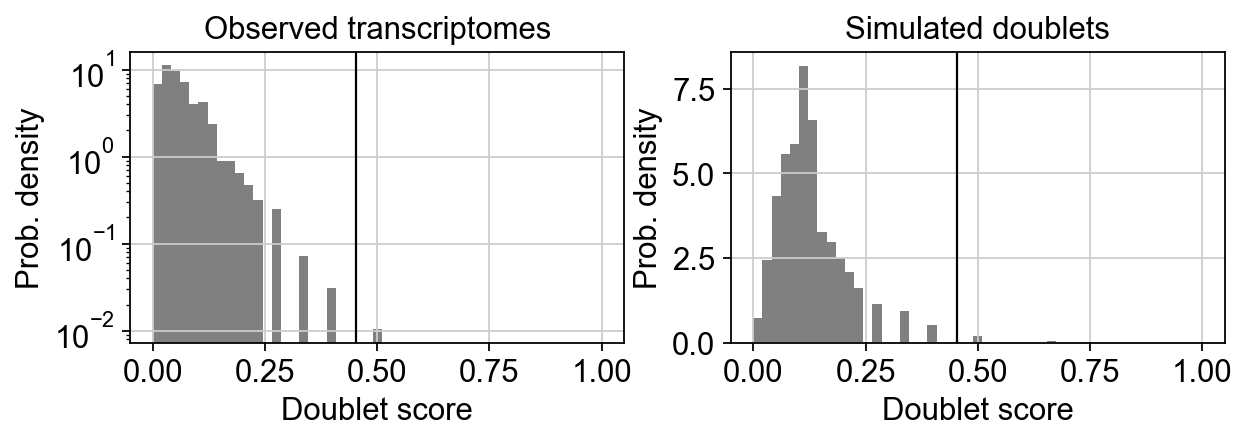

In [94]:
fig, ax = scrub.plot_histogram()

fig.savefig(
    "../../05_plots/02_Overview_and_doublet_analysis/16_scrublet_NK1.pdf",
    bbox_inches="tight",
    format="pdf",
    dpi=300
)

### Return the doublet scores to the dataframe

In [95]:
## Get annotation list
# Doublet scores per cell
scores = scrub.doublet_scores_obs_

## Use the bolean list to annotate csf cells
ddata["gex"].obs["scrublet_score"] = scores 

### Conventional processing and QC

In [96]:
#Annotate QC metrics but do not filter
ddata["gex"].var['mt'] = ddata["gex"].var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(ddata["gex"], qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [97]:
#All outliers across the three metrics

def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier
    
#All outliers across the three metrics
ddata["gex"].obs["outlier"] = (
    is_outlier(ddata["gex"], "total_counts", 8) |              #
    is_outlier(ddata["gex"], "n_genes_by_counts", 8) |
    is_outlier(ddata["gex"], "pct_counts_mt", 8)
).astype("category")
ddata["gex"].obs.outlier.value_counts()

outlier
False    4451
True      274
Name: count, dtype: int64

<Axes: xlabel='outlier', ylabel='pct_counts_mt'>

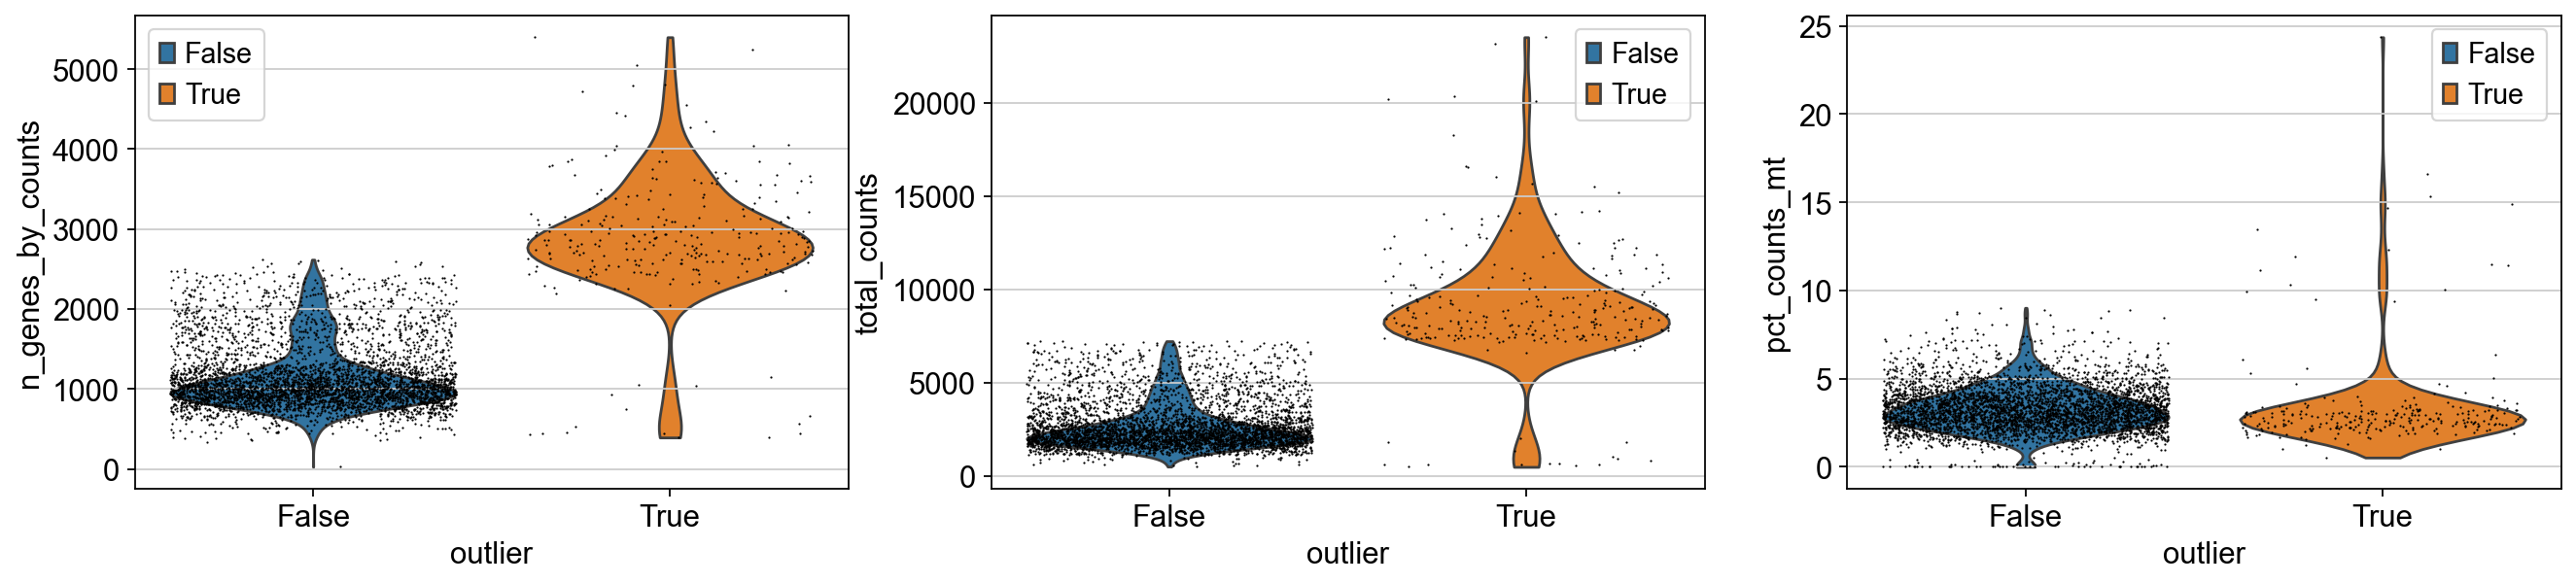

In [98]:
# Plot the QC metrics, and decide a cutoff %%%%%%%%%%%%
# Number of Axes & plot size
ncols = 3
nrows = 1
figsize = 4
wspace = 1

fig, axs = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(ncols * figsize + figsize * wspace * (ncols - 1), nrows * figsize),
)


# Plot individual values  
sc.pl.violin(
    ddata["gex"],
    keys="n_genes_by_counts",
    groupby='outlier',
    jitter=0.4,
    multi_panel=False,
    show=False,
    ax=axs[0]
)
sc.pl.violin(
    ddata["gex"],
    keys="total_counts",
    groupby="outlier",
    jitter=0.4,
    multi_panel=False,
    show=False,
    ax=axs[1]
)
sc.pl.violin(
    ddata["gex"],
    keys="pct_counts_mt",
    groupby="outlier",
    jitter=0.4,
    multi_panel=False,
    show=False,
    ax=axs[2]
)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
Filtering chains...
Indexing VJ chains...
Indexing VDJ chains...
build result array
Stored result in `mdata.obs["airr:receptor_type"]`.
Stored result in `mdata.obs["airr:receptor_subtype"]`.
Stored result in `mdata.obs["airr:chain_pairing"]`.


C:\Users\nipag\miniconda3\envs\py312_laptop\Lib\site-packages\mudata\_core\mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
C:\Users\nipag\miniconda3\envs\py312_laptop\Lib\site-packages\mudata\_core\mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


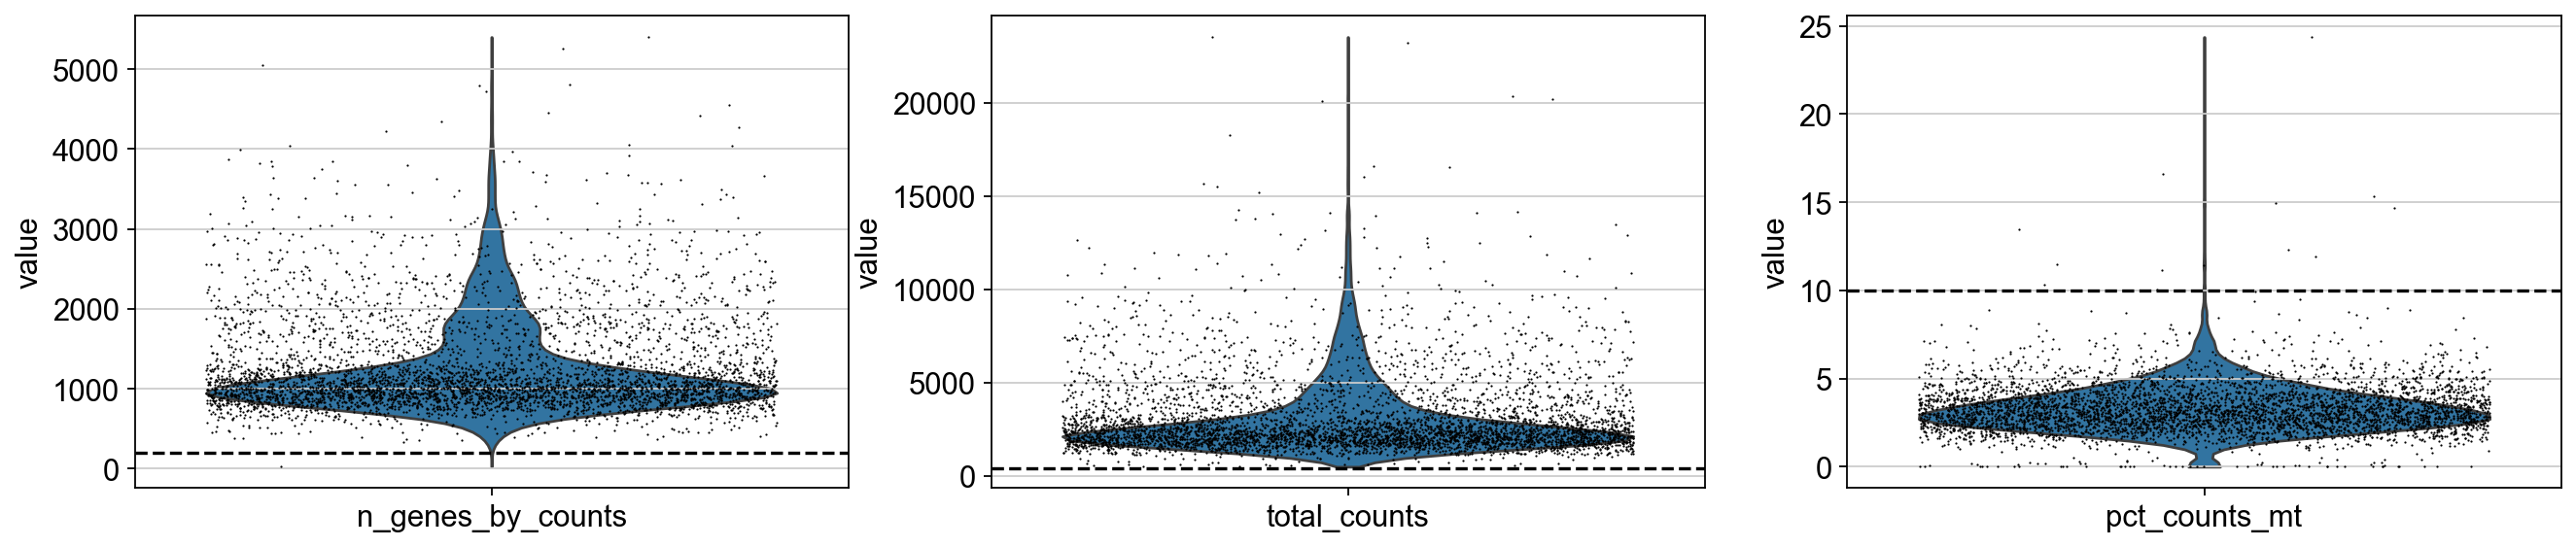

In [99]:
# Plot the QC metrics, and decide a cutoff %%%%%%%%%%%%
# Number of Axes & plot size
ncols = 3
nrows = 1
figsize = 4
wspace = 1

fig, axs = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(ncols * figsize + figsize * wspace * (ncols - 1), nrows * figsize),
)

# Plot individual values  
sc.pl.violin(
    ddata["gex"], 
    keys="n_genes_by_counts",
    jitter=0.4,
    multi_panel=False,
    show=False,
    ax=axs[0]
)
sc.pl.violin(
    ddata["gex"], 
    keys="total_counts",
    jitter=0.4,
    multi_panel=False,
    show=False,
    ax=axs[1]
)
sc.pl.violin(
    ddata["gex"], 
    keys="pct_counts_mt",
    jitter=0.4,
    multi_panel=False,
    show=False,
    ax=axs[2]
)

#n_genes_total (i.e. number of genes per cell)
axs[0].axhline(y=200, linewidth = 1.5, color = "black", linestyle = "--")

#number of total reads 
axs[1].axhline(y=400, linewidth = 1.5, color = "black", linestyle = "--")

#mitochondrial gene expression
axs[2].axhline(y=10, linewidth = 1.5, color = "black", linestyle = "--")

# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Update 2025_7
# Genes needs to be detected in at least 3 cells. 

# A general lower limit on the number of genes detected per cell
# CSF = 200

# A general lower limit on the total_reads detected per cell
# CSF = 400


# %%% Filter functions from muon. 
## filter_var indicates filtering on genes
mu.pp.filter_var(ddata["gex"], 'n_cells_by_counts', lambda x: x >= 3)

## filter_obs indicates filtering on observations (i.e. cells)
mu.pp.filter_obs(ddata["gex"], 'n_genes_by_counts', lambda x: (x >= 200)) 
mu.pp.filter_obs(ddata["gex"], 'total_counts', lambda x: (x > 400))
mu.pp.filter_obs(ddata["gex"], 'pct_counts_mt', lambda x: x < 10)

# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# Normalization steps %%%%%%%%%%%%%%%%
sc.pp.normalize_total(ddata["gex"])
sc.pp.log1p(ddata["gex"])
sc.pp.highly_variable_genes(ddata["gex"], n_top_genes=5000)
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

#TCR steps %%%%%%%%%%%%%%%%%%%%%%%%%%%
ir.pp.index_chains(ddata)
ir.tl.chain_qc(ddata)    #Chain QC
ddata.obs['airr:chain_pairing'].value_counts()
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

#Update
ddata.update()

#Define NA clonotypes as "No IR detected"
ddata.obs['airr:chain_pairing'] = ddata.obs['airr:chain_pairing'].fillna('no_IR')

#Transfer the chain_pairing information
ddata["gex"].obs['chain_pairing'] = ddata["airr"].obs['chain_pairing']

With the neighbourhood graph computed, we can now perform clustering. We will use leiden clustering as an example.

In [100]:
calculate_leiden(ddata["gex"], resolution=1, n_high_var=5000, remove_tcr_genes=True)
calculate_umap(ddata["gex"], n_high_var=5000, remove_tcr_genes=True)

extracting highly variable genes
    finished (0:00:00)


C:\Users\nipag\miniconda3\envs\py312_laptop\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:705: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


computing neighbors
computing PCA
    with n_comps=20


C:\Users\nipag\miniconda3\envs\py312_laptop\Lib\site-packages\scanpy\neighbors\__init__.py:586: UserWarning: You’re trying to run this on 5000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


    finished (0:00:00)
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
computing neighbors


C:\Users\nipag\miniconda3\envs\py312_laptop\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:705: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


computing PCA
    with n_comps=20


C:\Users\nipag\miniconda3\envs\py312_laptop\Lib\site-packages\scanpy\neighbors\__init__.py:586: UserWarning: You’re trying to run this on 5000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


    finished (0:00:00)
    finished (0:00:00)
computing UMAP
    finished (0:00:05)


In [101]:
ddata

MuData object with n_obs × n_vars = 4718 × 17320
  2 modalities
    gex:	4711 x 17320
      obs:	'scrublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'outlier', 'chain_pairing', 'leiden'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'outlier_colors', 'log1p', 'hvg'
      obsm:	'X_umap'
      layers:	'counts'
    airr:	3696 x 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing'
      uns:	'scirpy_version', 'chain_indices'
      obsm:	'airr', 'chain_indices'

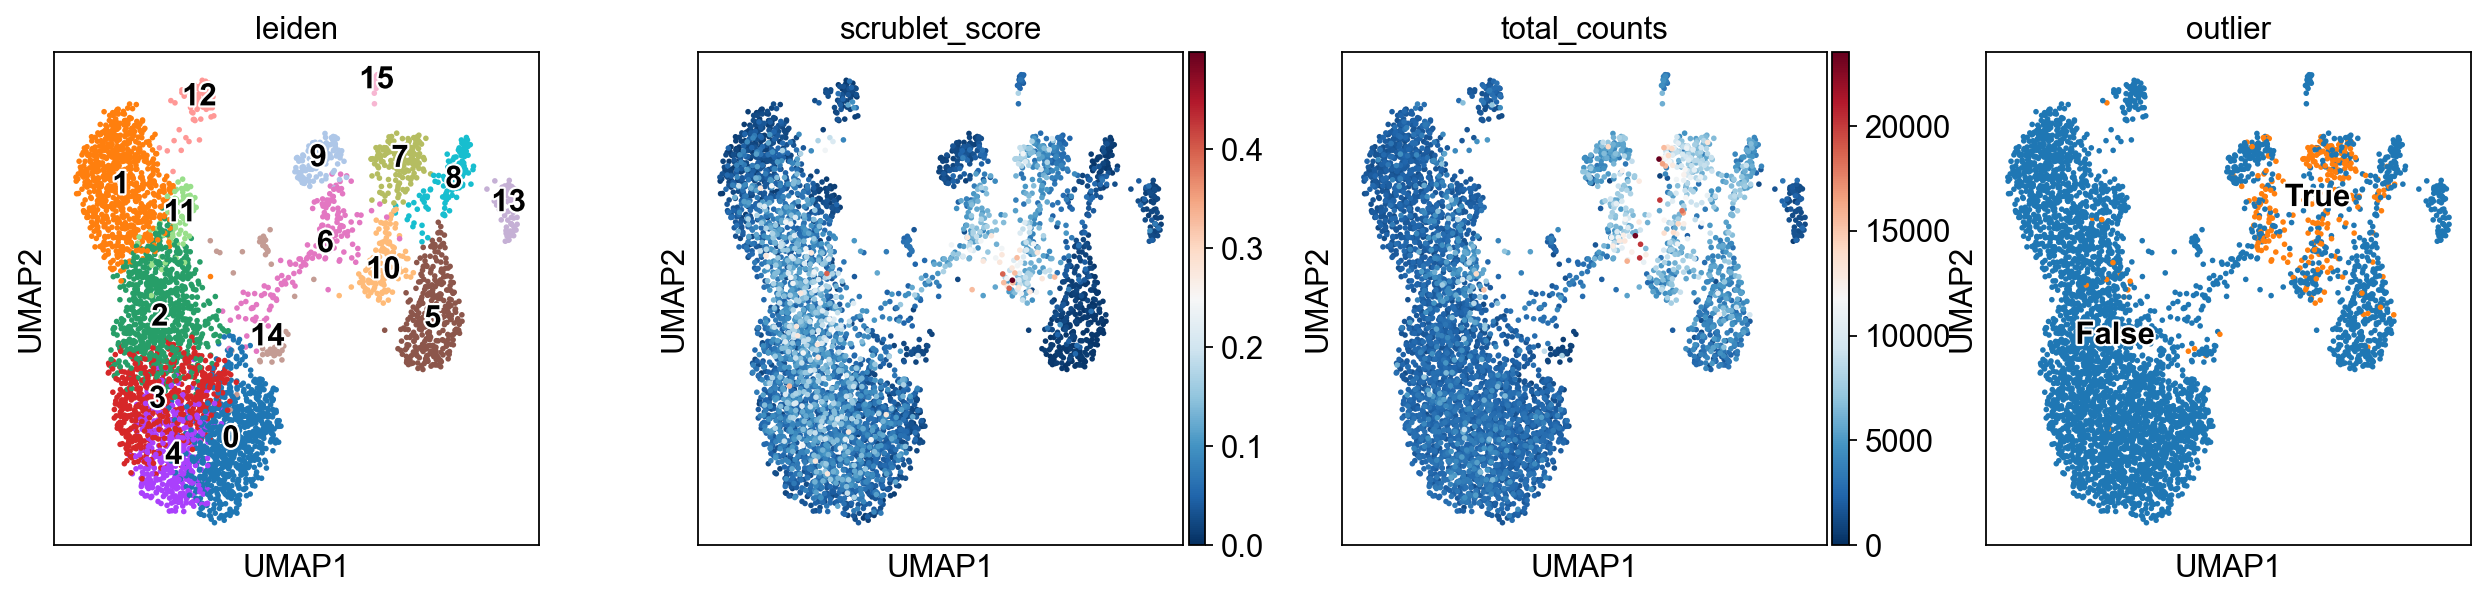

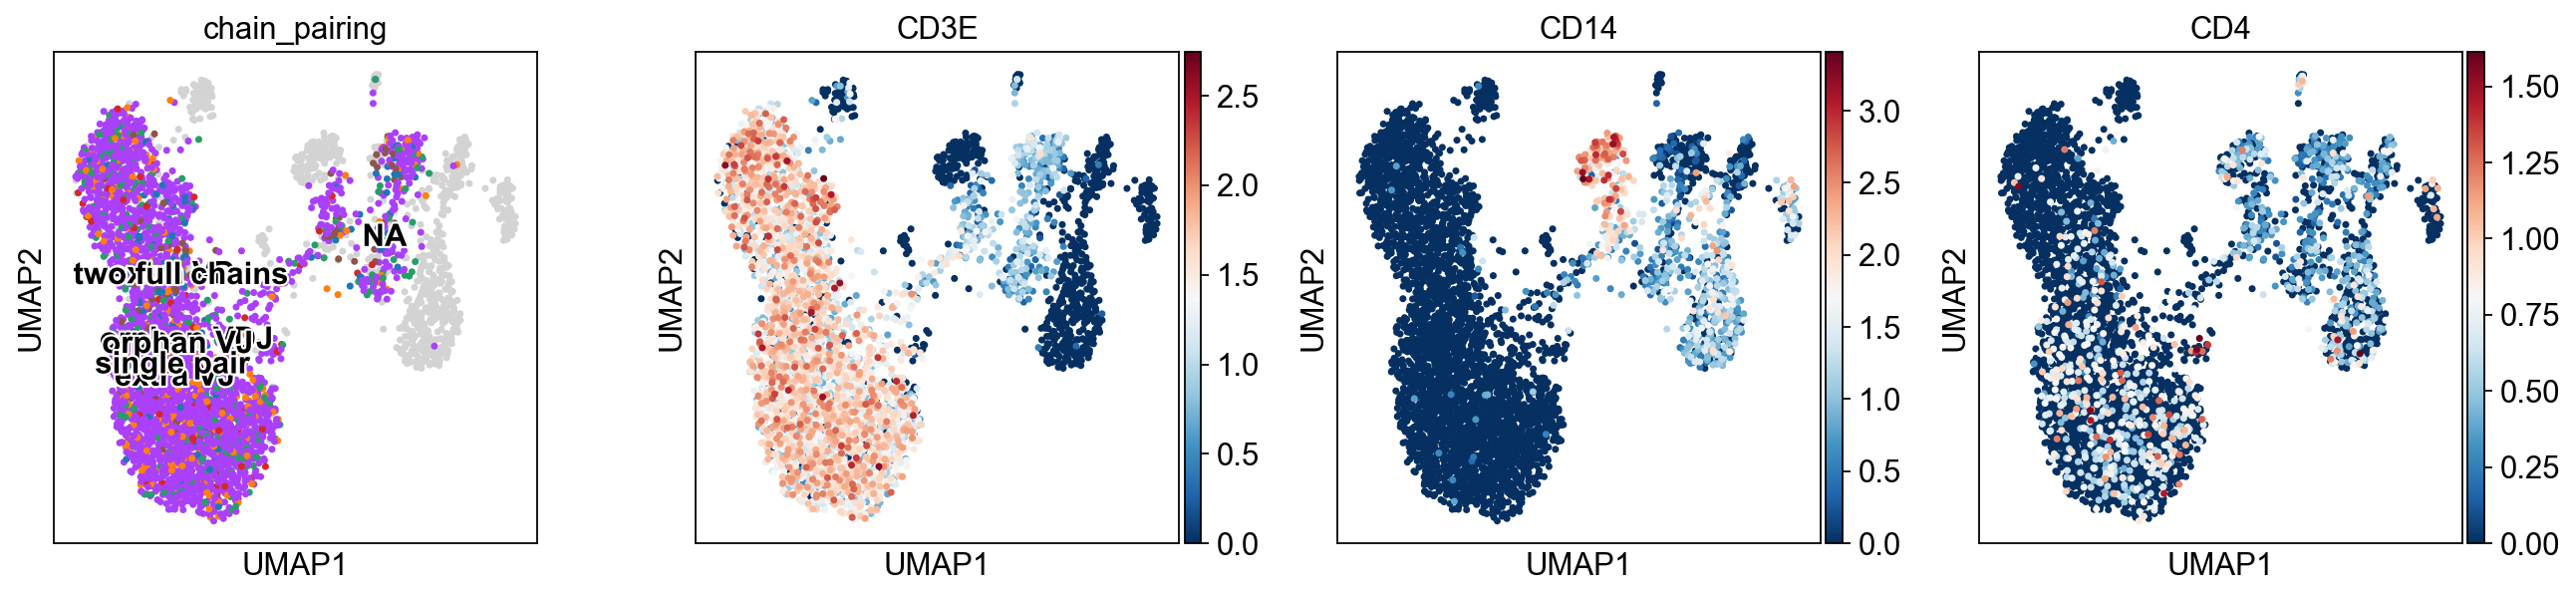

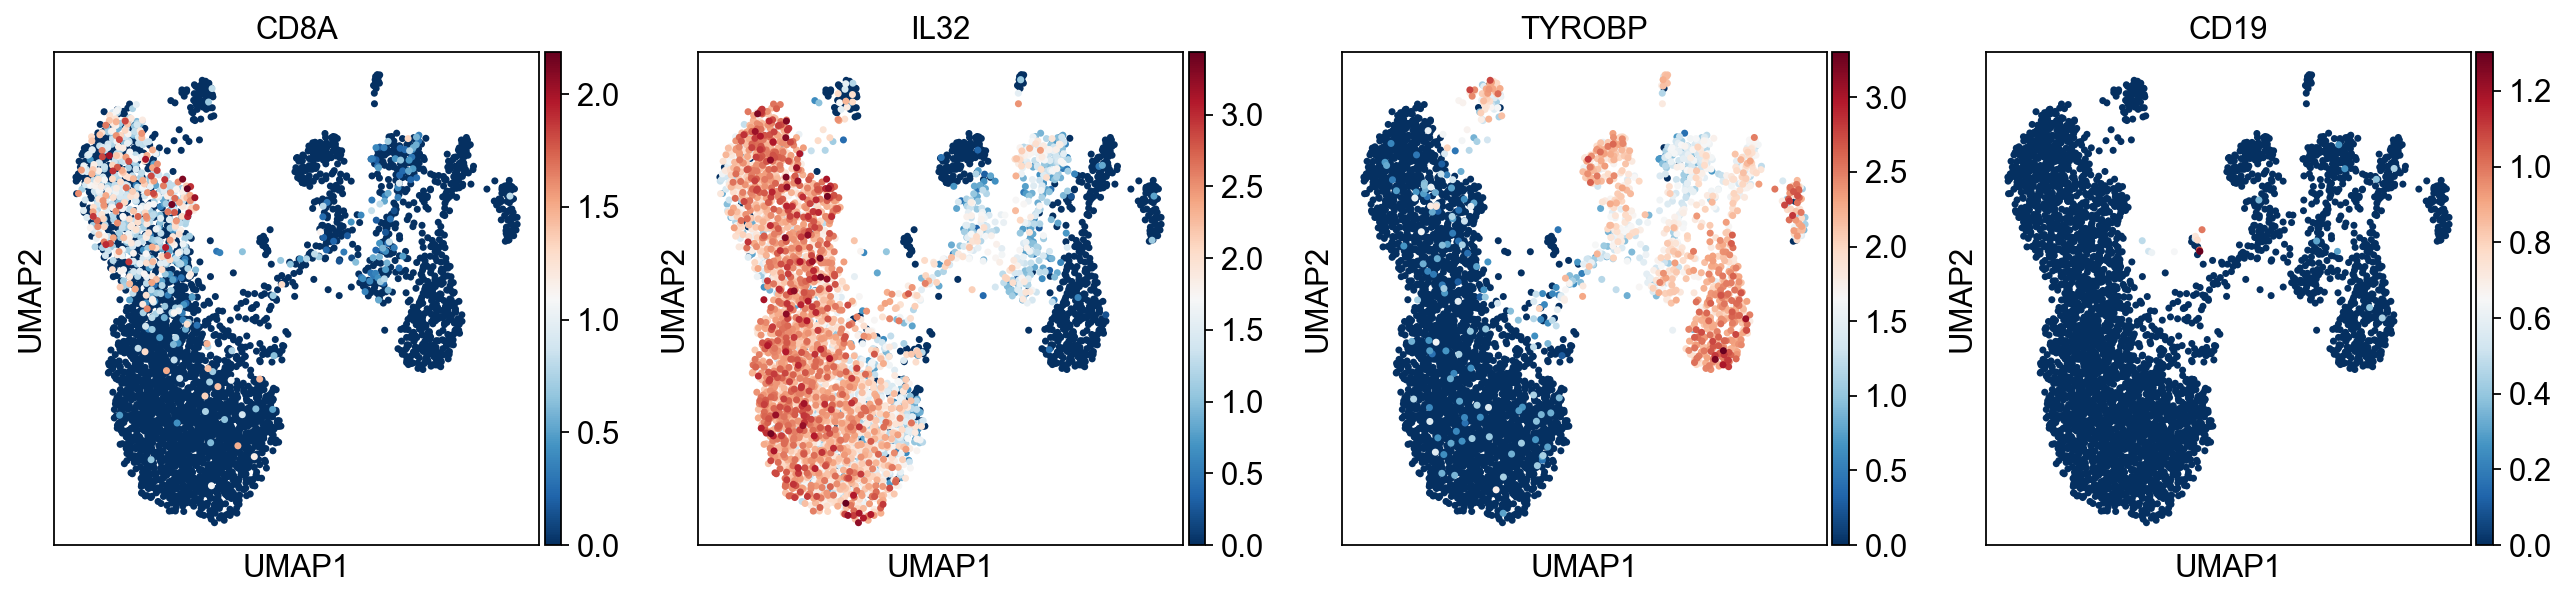

In [102]:
sc.pl.umap(ddata["gex"], color=["leiden", "scrublet_score", "total_counts", "outlier"], legend_loc="on data", legend_fontweight= 'bold', frameon= True , vmin=0, legend_fontoutline=2, cmap="RdBu_r")
sc.pl.umap(ddata["gex"], color=["chain_pairing", "CD3E", "CD14", "CD4"], legend_loc="on data", legend_fontweight= 'bold', frameon= True, size=40, vmin=0, legend_fontoutline=2, cmap="RdBu_r")
sc.pl.umap(ddata["gex"], color=["CD8A", "IL32", "TYROBP", "CD19"], legend_loc="on data", legend_fontweight= 'bold', frameon= True, size=40, vmin=0, legend_fontoutline=2, cmap="RdBu_r")

## Export pre-doublet removal data
With the following QC thresholds: 
* mu.pp.filter_var(ddata["gex"], 'n_cells_by_counts', lambda x: x >= 3)
* mu.pp.filter_obs(ddata["gex"], 'n_genes_by_counts', lambda x: (x >= 200))
* mu.pp.filter_obs(ddata["gex"], 'total_counts', lambda x: (x > 400))
* mu.pp.filter_obs(ddata["gex"], 'pct_counts_mt', lambda x: x < 8)

MAD score is set to 8

In [61]:
ddata.write(filename=r"C:\Users\nipag\coding\MS.schober\04_data_objects\01_preprocessed_scseq_scanpy\2025_12 - with EBV\NK_1.h5mu")

C:\Users\nipag\miniconda3\envs\py312_laptop\Lib\site-packages\mudata\_core\mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
C:\Users\nipag\miniconda3\envs\py312_laptop\Lib\site-packages\mudata\_core\mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [16]:
ddata

MuData object with n_obs × n_vars = 4723 × 17333
  2 modalities
    gex:	4716 x 17333
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'outlier', 'chain_pairing', 'leiden'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'outlier_colors', 'log1p', 'hvg', 'leiden_colors', 'airr:chain_pairing_colors'
      obsm:	'X_umap'
      layers:	'counts'
    airr:	3722 x 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing'
      uns:	'scirpy_version', 'chain_indices'
      obsm:	'airr', 'chain_indices'